# Analysis of Example 3: resolution, truncation and the harmonic limit

This notebook starts from the results of `examples/example3_chi5_2q.ipynb` and tests the fifth-order 2Q spectrum of the two-mode model. In this notebook you will:

- load the $\eta=8$ meV map, the seven pathways and the energies saved by the example;
- compute the same spectrum at a smaller broadening, $\eta=2$ meV, to resolve the poles;
- show which pathways need the three-excitation manifold;
- measure what is lost if the model is truncated at two excitations;
- check that the seven pathways cancel when the anharmonicities vanish.

Only the cases that differ from the example are computed here: the cutoff $N_{\max}=2$, the broadening $\eta=2$ meV, and the harmonic model.

Natural units: $\hbar=1$, energies in eV, times in eV$^{-1}$.

## 0. Imports

`models.py` in the parent folder builds the two-mode model (QuTiP operators restricted to $n_h+n_l\le N_{\max}$), its UFSS pathways and the protocol, for any cutoff and any anharmonicities. Figures are saved in `results/figure_analysis/`. The first cell limits BLAS to one thread, which is faster for matrices this small.

In [1]:
import os

for variable in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(variable, "1")

import sys

sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np

from qudpy_fdgf import SpectroscopySolver
from models import (ANALYSIS_FIGURES, DATA, EX3_AXES, EX3_FIXED, EX3_PROTOCOL, example3_model,
                    example3_pathways, results_dirs)

results_dirs()

(WindowsPath('C:/Users/falve/OneDrive/Documents/GitHub/QuDPy-FDGF/validation/results/data'),
 WindowsPath('C:/Users/falve/OneDrive/Documents/GitHub/QuDPy-FDGF/validation/results/figure'),
 WindowsPath('C:/Users/falve/OneDrive/Documents/GitHub/QuDPy-FDGF/validation/results/figure_analysis'))

## 1. Results of the example

From the saved file we need the grid, the $N_{\max}=3$, $\eta=8$ meV spectrum, the pathway maps with their interaction labels, and the eigenenergies per manifold.

In [2]:
saved = np.load(DATA / "example3.npz")
omega_2q, omega_emit = saved["omega_2q"], saved["omega_emit"]
reference = {
    "spectrum": saved["spectrum"],
    "pathways": dict(zip(saved["pathway_names"], saved["pathway_maps"])),
    "labels": dict(zip(saved["pathway_names"], (tuple(s.split()) for s in saved["pathway_labels"]))),
}
energies = saved["energies"]
epsilon, E_two, E_three = energies[1:3], energies[3:6], energies[6:10]

print(f"eta = {float(saved['eta'])} eV, N_max = {int(saved['max_manifold'])}, grid {reference['spectrum'].shape}, "
      f"{len(reference['pathways'])} pathways")

eta = 0.008 eV, N_max = 3, grid (151, 151), 7 pathways


## 2. A function for the other cases

`calculate_case` repeats the calculation of the example for a given cutoff, broadening, grid and set of anharmonicities, and returns the spectrum with its pathways.

In [3]:
def calculate_case(max_manifold, eta, axes=None, anharmonicities=None):
    axes = {"omega_2q": omega_2q, "omega_emit": omega_emit} if axes is None else axes
    pathways = example3_pathways(max_manifold)
    solver = SpectroscopySolver(backend="dense", eta=eta, max_cache_entries=4096)
    solver.feed_model(example3_model(max_manifold, anharmonicities))
    solver.set_pathways(pathways)
    result = solver.generate_nq_spectrum(2, EX3_PROTOCOL, axes=axes, fixed_coordinates=EX3_FIXED, pathways=pathways)
    return {
        "spectrum": result.components["chi5_2q"],
        "pathways": {p.name: result.pathways[p.name] for p in pathways},
        "labels": {p.name: tuple(i.label for i in p.interactions) for p in pathways},
    }


def plot_abs_map(spectrum, title, name):
    magnitude = np.abs(spectrum)
    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    image = ax.imshow(
        magnitude / magnitude.max(), origin="lower", aspect="auto", cmap="magma", vmin=0, vmax=1,
        extent=(omega_emit[0], omega_emit[-1], omega_2q[0], omega_2q[-1]),
    )
    for energy in E_two:
        ax.axhline(-energy, color="white", lw=0.8, alpha=0.55)
    ax.set_xlabel(r"Emission energy $\omega_{\mathrm{emit}}$ (eV)")
    ax.set_ylabel(r"Double-quantum energy $\omega_{2Q}$ (eV)")
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label=r"$|S|/|S|_{\max}$")
    fig.savefig(ANALYSIS_FIGURES / name, bbox_inches="tight")
    plt.show()

## 3. Resolved structure at $\eta=2$ meV

Neighbouring poles that overlap at $\eta=8$ meV separate at 2 meV. We compute the converged model ($N_{\max}=3$) at $\eta=2$ meV and compare it with the example.

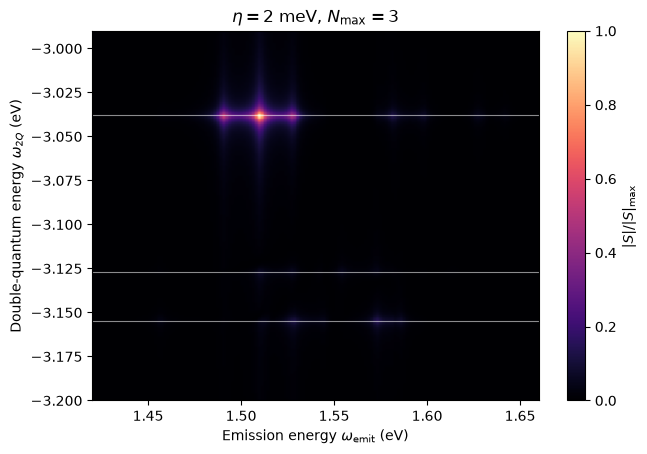

peak ratio eta=2 / eta=8: 18.27   (ideal eta^-2 scaling: 16)


In [4]:
case_eta2 = calculate_case(3, 0.002)

plot_abs_map(case_eta2["spectrum"], r"$\eta=2$ meV, $N_{\max}=3$", "example3_eta2_map.pdf")
peak_ratio = np.abs(case_eta2["spectrum"]).max() / np.abs(reference["spectrum"]).max()
print(f"peak ratio eta=2 / eta=8: {peak_ratio:.2f}   (ideal eta^-2 scaling: 16)")
assert 10 < peak_ratio < 25

The three horizontal groups sit at the two-excitation energies $-E_k$ (white lines). Along the emission axis, the pathways end in one of three $q=+1$ coherences:

$$|1\rangle\langle g|,\qquad|2\rangle\langle1|,\qquad|3\rangle\langle2|,$$

with poles at $\varepsilon_j$, $E_k-\varepsilon_j$ and $E^{(3)}_m-E_k$. Reducing $\eta$ by four increases the maximum by a factor close to $\eta^{-2}$, as expected when the two frequency-domain resolvents are simultaneously near resonance. Deviations from 16 come from the finite grid, overlapping poles and interference.

## 4. Pathway completeness

The last three interactions of a pathway can be $K_u$ or $B_d$, giving $2^3=8$ orderings. UFSS generates seven. We compare their amplitudes at the strongest feature $(-E_1,E_1-\varepsilon_1)$ for $N_{\max}=2$ (computed here) and $N_{\max}=3$ (from the example).

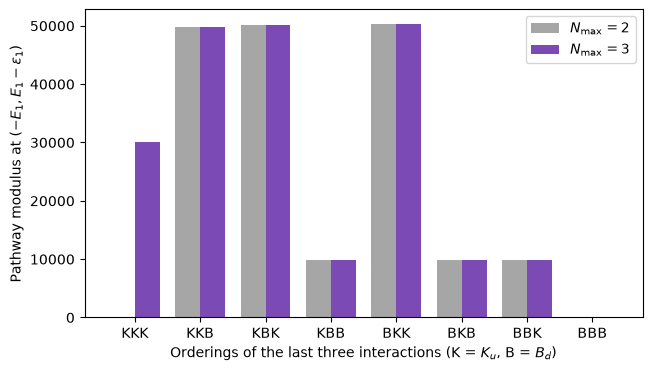

orderings never generated: ['BBB']
all-Ku (KKK): N_max=2 -> 0.00e+00, N_max=3 -> 3.01e+04


In [5]:
case_n2_eta8 = calculate_case(2, 0.008)
orderings = ("KKK", "KKB", "KBK", "KBB", "BKK", "BKB", "BBK", "BBB")


def ordering_key(labels):
    return "".join("K" if label == "Ku" else "B" for label in labels[2:])


def amplitudes_at(case, w_2q, w_emit):
    row = int(np.argmin(np.abs(omega_2q - w_2q)))
    col = int(np.argmin(np.abs(omega_emit - w_emit)))
    values = dict.fromkeys(orderings, 0.0)
    for name, labels in case["labels"].items():
        values[ordering_key(labels)] = abs(case["pathways"][name][row, col])
    return values


amp_n2 = amplitudes_at(case_n2_eta8, -E_two[0], E_two[0] - epsilon[0])
amp_n3 = amplitudes_at(reference, -E_two[0], E_two[0] - epsilon[0])

x, width = np.arange(len(orderings)), 0.38
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.bar(x - width / 2, [amp_n2[k] for k in orderings], width, label=r"$N_{\max}=2$", color="0.65")
ax.bar(x + width / 2, [amp_n3[k] for k in orderings], width, label=r"$N_{\max}=3$", color="#7b4ab5")
ax.set_xticks(x, orderings)
ax.set_ylabel(r"Pathway modulus at $(-E_1,E_1-\varepsilon_1)$")
ax.set_xlabel("Orderings of the last three interactions (K = $K_u$, B = $B_d$)")
ax.legend()
fig.savefig(ANALYSIS_FIGURES / "example3_pathway_orderings.pdf", bbox_inches="tight")
plt.show()

generated = {ordering_key(labels) for labels in reference["labels"].values()}
print("orderings never generated:", [k for k in orderings if k not in generated])
print(f"all-Ku (KKK): N_max=2 -> {amp_n2['KKK']:.2e}, N_max=3 -> {amp_n3['KKK']:.2e}")
assert [k for k in orderings if k not in generated] == ["BBB"]
assert amp_n2["KKK"] == 0.0 and amp_n3["KKK"] > 0.0

Six pathways are identical at both cutoffs, since their density matrices never leave the $N\le2$ blocks. The all-$K_u$ pathway reaches three excitations: it vanishes at $N_{\max}=2$ and is finite at $N_{\max}=3$. The all-$B_d$ ordering would lower the bra below the ground state and is zero at any cutoff, so seven pathways form the complete set. This follows from the ladder structure of the transition operators; no extra rule is imposed during propagation.

## 5. Spectral consequence of truncating at two excitations

A cut along $\omega_{2Q}=-E_1$ at $\eta=2$ meV shows where the missing pathway contributes. Green lines mark the transitions $E^{(3)}_m-E_k$.

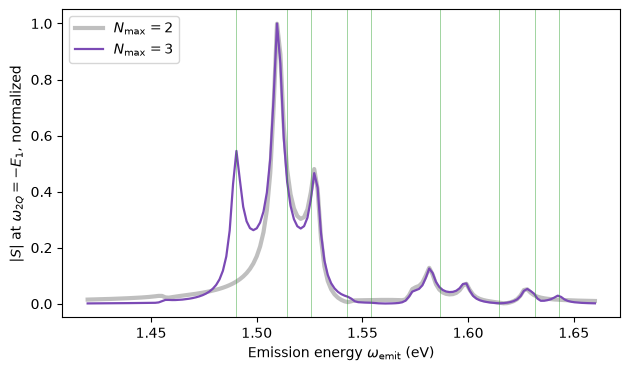

eta=8 meV: N_max=2 peak +12.59 %, spectra differ by 63.5 % of the maximum
eta=2 meV: N_max=2 peak -0.08 %, spectra differ by 53.4 % of the maximum


In [6]:
case_n2_eta2 = calculate_case(2, 0.002)
row = int(np.argmin(np.abs(omega_2q + E_two[0])))
cut_n2 = np.abs(case_n2_eta2["spectrum"][row])
cut_n3 = np.abs(case_eta2["spectrum"][row])

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(omega_emit, cut_n2 / cut_n3.max(), lw=3.0, color="0.75", label=r"$N_{\max}=2$")
ax.plot(omega_emit, cut_n3 / cut_n3.max(), lw=1.6, color="#7b4ab5", label=r"$N_{\max}=3$")
for transition in (E_three[:, None] - E_two[None, :]).ravel():
    if omega_emit[0] <= transition <= omega_emit[-1]:
        ax.axvline(transition, color="#2ca02c", lw=0.7, alpha=0.45)
ax.set_xlabel(r"Emission energy $\omega_{\mathrm{emit}}$ (eV)")
ax.set_ylabel(r"$|S|$ at $\omega_{2Q}=-E_1$, normalized")
ax.legend()
fig.savefig(ANALYSIS_FIGURES / "example3_truncation_cut.pdf", bbox_inches="tight")
plt.show()

for label, (small, full) in {"eta=8 meV": (case_n2_eta8, reference), "eta=2 meV": (case_n2_eta2, case_eta2)}.items():
    top = np.abs(full["spectrum"]).max()
    peak_change = np.abs(small["spectrum"]).max() / top - 1.0
    difference = np.abs(small["spectrum"] - full["spectrum"]).max() / top
    print(f"{label}: N_max=2 peak {100 * peak_change:+.2f} %, spectra differ by {100 * difference:.1f} % of the maximum")

The largest difference sits near the $E^{(3)}_m-E_k$ transitions, where $N_{\max}=3$ has a resonance that $N_{\max}=2$ lacks. The truncation removes genuine spectral structure rather than rescaling the spectrum. Because pathway amplitudes are complex, the missing resonance can also shift the dominant peak by interference when the broadening is large.

## 6. Harmonic-limit cancellation

For a harmonic system driven linearly there is no nonlinear response: the seven fifth-order pathways must cancel exactly. We set all anharmonicities to zero and keep the full three-manifold calculation. A coarse $9\times9$ grid is enough, because the test concerns cancellation, not peak position.

In [7]:
coarse = {"omega_2q": np.linspace(omega_2q[0], omega_2q[-1], 9), "omega_emit": np.linspace(omega_emit[0], omega_emit[-1], 9)}
harmonic = calculate_case(3, 0.008, axes=coarse, anharmonicities=(0.0, 0.0, 0.0))

largest = max(np.abs(values).max() for values in harmonic["pathways"].values())
cancellation = np.abs(harmonic["spectrum"]).max() / largest
print(f"max |total| / max |single pathway| = {cancellation:.1e}")
assert cancellation < 1e-10

max |total| / max |single pathway| = 2.6e-13


The total is smaller than the largest single pathway by more than ten orders of magnitude. The cutoff $N_{\max}=3$ does not create an artificial fifth-order response, because no selected pathway needs four excitations. A calculation truncated at $N_{\max}=2$ drops the all-$K_u$ pathway and cannot cancel. This is a second reason, besides the missing resonance, to keep the three-excitation manifold.

## Summary

- At $\eta=2$ meV the three families of poles ($\varepsilon_j$, $E_k-\varepsilon_j$, $E^{(3)}_m-E_k$) become visible, and the maximum grows close to $\eta^{-2}$.
- Seven pathways form the complete set; only the all-$K_u$ pathway needs the three-excitation manifold.
- Truncating at two excitations removes a real resonance and breaks the harmonic cancellation.
- With zero anharmonicity the fifth-order response vanishes to numerical precision.